In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set Paths
DATASET_PATH = "/Users/ronitgandhi/Desktop/DL_for_classification/EuroSAT_RGB"  # Change this if needed

# Image Properties
IMG_SIZE = (256, 256)
BATCH_SIZE = 32

# Define Data Generators (80% Train, 20% Validation)
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# Load Training Data
train_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

# Load Validation Data
val_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# Print Class Labels (Confirming folder structure)
print(f"Class Labels: {train_data.class_indices}")


Found 21600 images belonging to 10 classes.
Found 5400 images belonging to 10 classes.
Class Labels: {'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Build CNN Model
model = Sequential([
    # First Convolutional Block
    Conv2D(64, (3,3), activation='relu', input_shape=(256, 256, 3)),
    MaxPooling2D(2,2),

    # Second Convolutional Block
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Third Convolutional Block
    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Flatten the Features
    Flatten(),

    # Fully Connected Layer
    Dense(512, activation='relu'),
    Dropout(0.3),

    # Output Layer (Softmax for multi-class classification)
    Dense(train_data.num_classes, activation='softmax')
])

# Compile the Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Print Model Summary
model.summary()


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 230400)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │   117,965,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,341,258 (451.44 MB)

 Trainable params: 118,341,258 (451.44 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Train the model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,  # Increase epochs if needed
    batch_size=BATCH_SIZE
)

# Save Model
model.save('land_classification_model.h5')


Epoch 1/10


/opt/anaconda3/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


675/675 ━━━━━━━━━━━━━━━━━━━━ 1460s 2s/step - accuracy: 0.3924 - loss: 1.7234 - val_accuracy: 0.6798 - val_loss: 0.9121
Epoch 2/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 1438s 2s/step - accuracy: 0.6771 - loss: 0.9085 - val_accuracy: 0.7439 - val_loss: 0.7024
Epoch 3/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 1051s 2s/step - accuracy: 0.7714 - loss: 0.6374 - val_accuracy: 0.7974 - val_loss: 0.5833
Epoch 4/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 1060s 2s/step - accuracy: 0.8440 - loss: 0.4502 - val_accuracy: 0.8452 - val_loss: 0.4760
Epoch 5/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 1203s 2s/step - accuracy: 0.8902 - loss: 0.3216 - val_accuracy: 0.8113 - val_loss: 0.6430
Epoch 6/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 1248s 2s/step - accuracy: 0.9210 - loss: 0.2387 - val_accuracy: 0.8187 - val_loss: 0.5719
Epoch 7/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 1060s 2s/step - accuracy: 0.9442 - loss: 0.1752 - val_accuracy: 0.8524 - val_loss: 0.5170
Epoch 8/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 1056s 2s/step - accuracy: 0.9634 - loss: 0.1163 - val_accurac

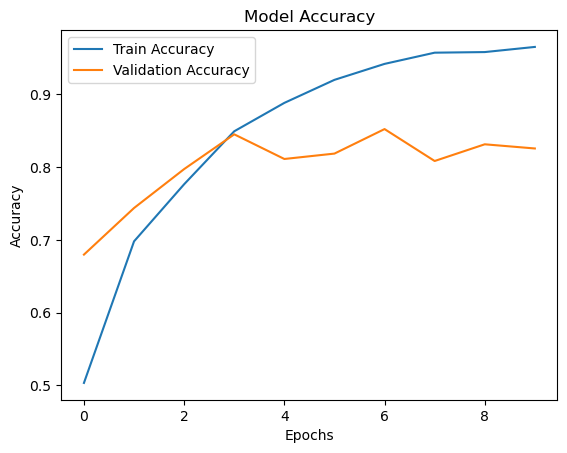

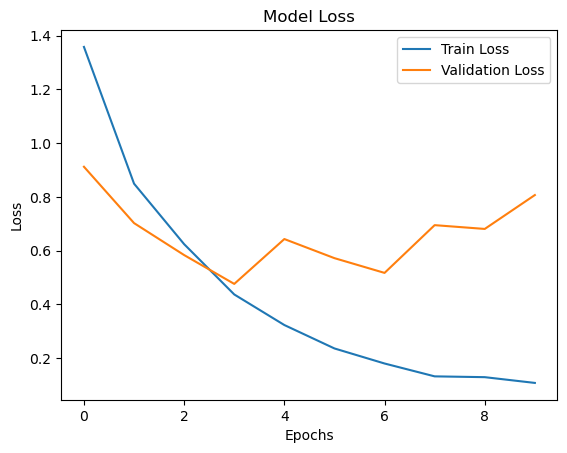

In [7]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.show()

# Plot Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.show()


In [16]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Load Image
img_path = "/Users/ronitgandhi/Desktop/DL_for_classification/test_images/landsat8_forest.png"  # Replace with an actual test image path
img = image.load_img(img_path, target_size=IMG_SIZE)

# Convert Image to Array
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
img_array /= 255.0  # Normalize

# Make Prediction
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)

# Map Prediction to Class Name
class_labels = list(train_data.class_indices.keys())
print(f"Predicted Class: {class_labels[predicted_class]}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Predicted Class: River
